**Source:** https://www.kaggle.com/datasets/ziya07/smart-mobility-traffic-dataset

In [ ]:
import kagglehub
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
# Download latest version
path = kagglehub.dataset_download("ziya07/smart-mobility-traffic-dataset")
print("Path to dataset files:", path)

csv_path = os.path.join(path, "smart_mobility_dataset.csv")
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
print(df.info())
print(df.head())
print(df.describe())
df.isnull().sum().sort_values(ascending=False)

Path to dataset files: /kaggle/input/smart-mobility-traffic-dataset
Shape: (5000, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Timestamp               5000 non-null   object 
 1   Latitude                5000 non-null   float64
 2   Longitude               5000 non-null   float64
 3   Vehicle_Count           5000 non-null   int64  
 4   Traffic_Speed_kmh       5000 non-null   float64
 5   Road_Occupancy_%        5000 non-null   float64
 6   Traffic_Light_State     5000 non-null   object 
 7   Weather_Condition       5000 non-null   object 
 8   Accident_Report         5000 non-null   int64  
 9   Sentiment_Score         5000 non-null   float64
 10  Ride_Sharing_Demand     5000 non-null   int64  
 11  Parking_Availability    5000 non-null   int64  
 12  Emission_Levels_g_km    5000 non-null   float64
 13  Energy_

,0
Timestamp,0
Latitude,0
Longitude,0
Vehicle_Count,0
Traffic_Speed_kmh,0
Road_Occupancy_%,0
Traffic_Light_State,0
Weather_Condition,0
Accident_Report,0
Sentiment_Score,0


In [ ]:
df['Timestamp'] = pd.to_datetime(df['Timestamp'], utc=True, errors='coerce')
df['Hour'] = df['Timestamp'].dt.hour
df['DayOfWeek'] = df['Timestamp'].dt.dayofweek  # Monday=0, Sunday=6
df['Month'] = df['Timestamp'].dt.month
df.drop(columns=['Timestamp'], inplace=True)

df = pd.get_dummies(df, columns=['Traffic_Light_State', 'Weather_Condition'])

from sklearn.preprocessing import OrdinalEncoder
# Define custom order
custom_order = [['Low', 'Medium', 'High']]

# Reshape y into 2D (required by OrdinalEncoder)
oe = OrdinalEncoder(categories=custom_order)
y_encoded = oe.fit_transform(df[['Traffic_Condition']])
df['Traffic_Condition'] = y_encoded

# Flatten it back to 1D if needed
y_encoded = y_encoded.ravel()

scaler = StandardScaler()
num_cols = [
    'Vehicle_Count',
    'Traffic_Speed_kmh',
    'Road_Occupancy_%',
    'Sentiment_Score',
    'Ride_Sharing_Demand',
    'Parking_Availability',
    'Emission_Levels_g_km',
    'Energy_Consumption_L_h',
    'Latitude',
    'Longitude'
]

df[num_cols] = scaler.fit_transform(df[num_cols])

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop('Traffic_Condition', axis=1)
y = df['Traffic_Condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-5-1401020051.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


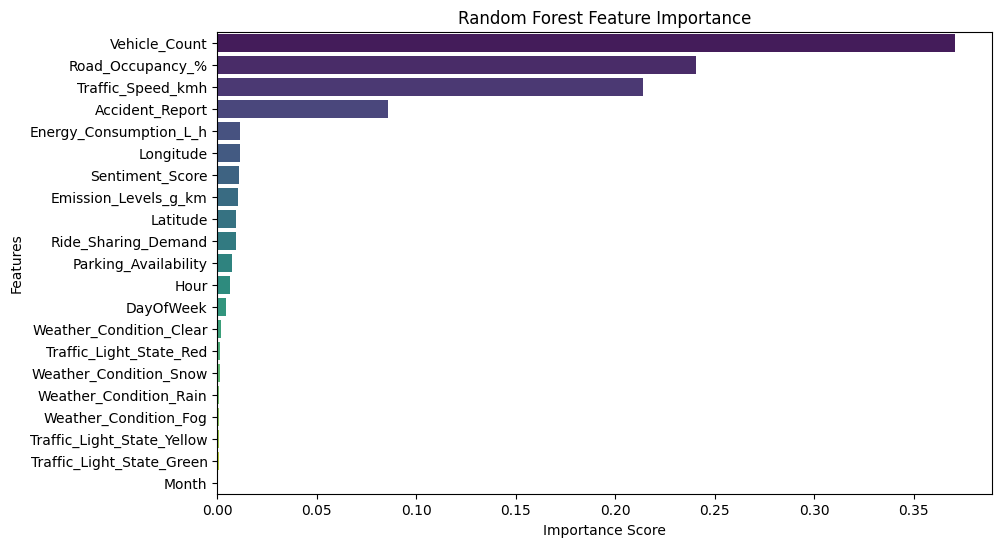


Feature Importance Scores:
                   Feature  Importance
             Vehicle_Count    0.370883
          Road_Occupancy_%    0.240771
         Traffic_Speed_kmh    0.213871
           Accident_Report    0.085665
    Energy_Consumption_L_h    0.011218
                 Longitude    0.011183
           Sentiment_Score    0.011112
      Emission_Levels_g_km    0.010429
                  Latitude    0.009295
       Ride_Sharing_Demand    0.009158
      Parking_Availability    0.007489
                      Hour    0.006564
                 DayOfWeek    0.004180
   Weather_Condition_Clear    0.001715
   Traffic_Light_State_Red    0.001385
    Weather_Condition_Snow    0.001350
    Weather_Condition_Rain    0.001098
     Weather_Condition_Fog    0.000948
Traffic_Light_State_Yellow    0.000849
 Traffic_Light_State_Green    0.000837
                     Month    0.000000


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

In [ ]:
# Drop feature(s) with zero importance
df.drop(columns=['Month'], inplace=True)

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        60
         1.0       0.99      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 58   2   0]
 [  0 307   0]
 [  0   0 633]]


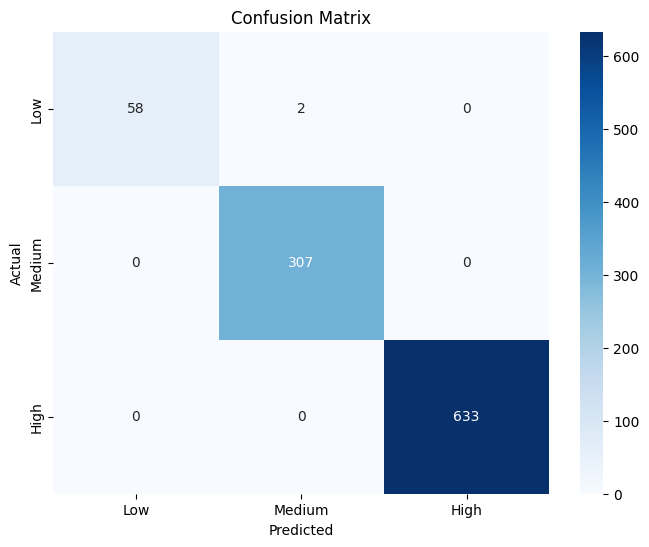

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1_macro',
    cv=5,  # 5-fold cross-validation
    n_jobs=-1,  # Use all cores for faster search
    verbose=1   # Shows progress
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
Best F1 Score: 0.9927


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.97      0.98        60
         1.0       0.99      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      0.99      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 58   2   0]
 [  0 307   0]
 [  0   0 633]]


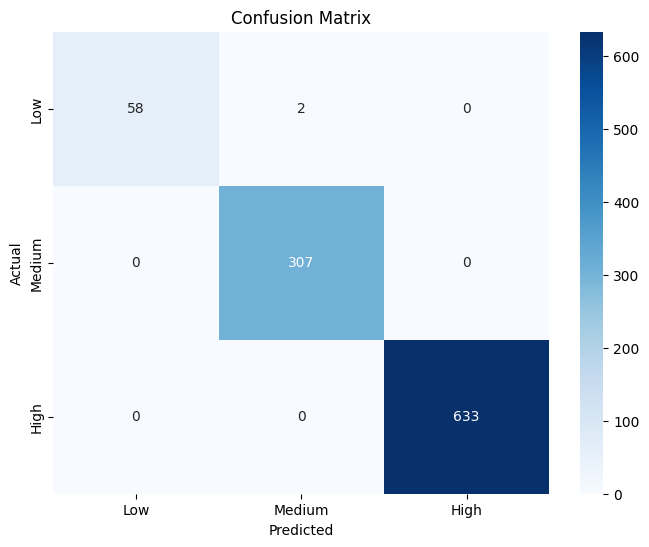

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression


# Define features and target
X = df.drop('Traffic_Condition', axis=1)
y = df['Traffic_Condition']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000, solver='lbfgs')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-5-1923336454.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


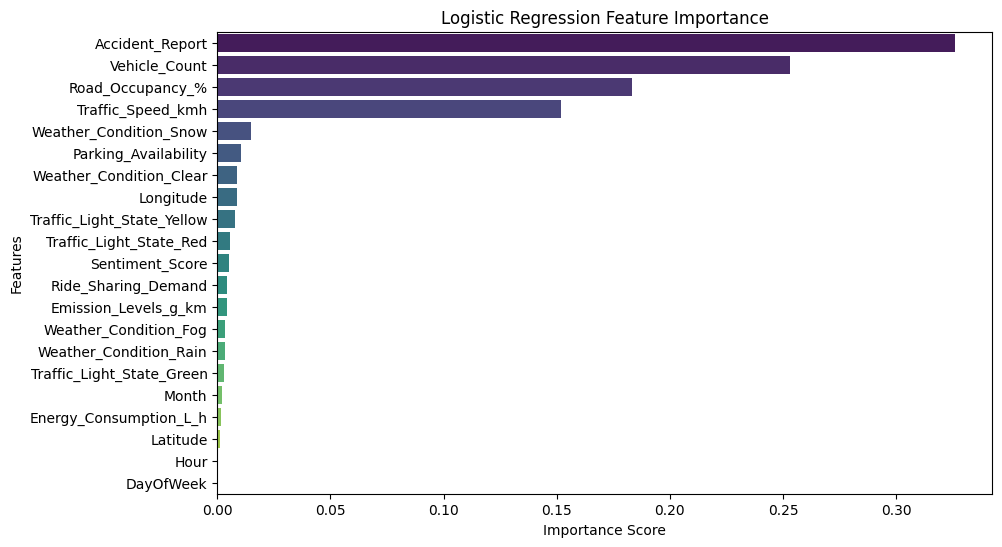


Feature Importance (Logistic Regression):
       Latitude: 0.001133
      Longitude: 0.008563
  Vehicle_Count: 0.253097
Traffic_Speed_kmh: 0.151826
Road_Occupancy_%: 0.183282
Accident_Report: 0.326171
Sentiment_Score: 0.005345
Ride_Sharing_Demand: 0.004448
Parking_Availability: 0.010551
Emission_Levels_g_km: 0.004179
Energy_Consumption_L_h: 0.001854
           Hour: 0.000431
      DayOfWeek: 0.000384
          Month: 0.001935
Traffic_Light_State_Green: 0.002795
Traffic_Light_State_Red: 0.005641
Traffic_Light_State_Yellow: 0.007791
Weather_Condition_Clear: 0.008738
Weather_Condition_Fog: 0.003505
Weather_Condition_Rain: 0.003366
Weather_Condition_Snow: 0.014964


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Logistic Regression Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (Logistic Regression):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.76

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.67      0.68        60
         1.0       0.62      0.57      0.59       307
         2.0       0.83      0.86      0.84       633

    accuracy                           0.76      1000
   macro avg       0.72      0.70      0.71      1000
weighted avg       0.75      0.76      0.76      1000


Confusion Matrix:
[[ 40  20   0]
 [ 17 175 115]
 [  0  88 545]]


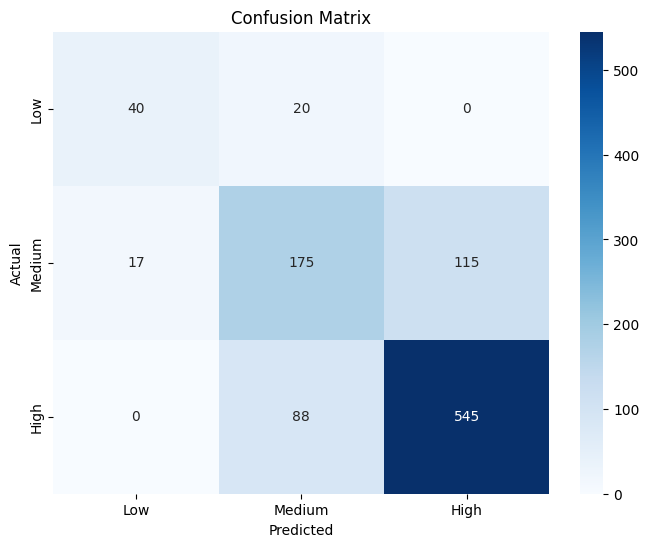

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
log_reg = LogisticRegression(max_iter=1000)

param_grid_log = {
    'C': [0.01, 0.1, 1, 10, 100],  # Regularization strength
    'solver': ['lbfgs', 'liblinear'],  # Optimization algorithm
    'penalty': ['l2']  # 'l1' works with 'liblinear' only
}

grid_log = GridSearchCV(log_reg, param_grid_log, cv=5, scoring='accuracy', n_jobs=-1)
grid_log.fit(X_train, y_train)

print("Best Logistic Regression Params:", grid_log.best_params_)
print("Best Logistic Regression Score:", grid_log.best_score_)

best_log_model = grid_log.best_estimator_
y_pred = best_log_model.predict(X_test)

Best Logistic Regression Params: {'C': 10, 'penalty': 'l2', 'solver': 'lbfgs'}
Best Logistic Regression Score: 0.7849999999999999


Accuracy: 0.77

Classification Report:
              precision    recall  f1-score   support

         0.0       0.71      0.75      0.73        60
         1.0       0.63      0.57      0.60       307
         2.0       0.83      0.86      0.84       633

    accuracy                           0.77      1000
   macro avg       0.72      0.73      0.72      1000
weighted avg       0.76      0.77      0.76      1000


Confusion Matrix:
[[ 45  15   0]
 [ 18 175 114]
 [  0  88 545]]


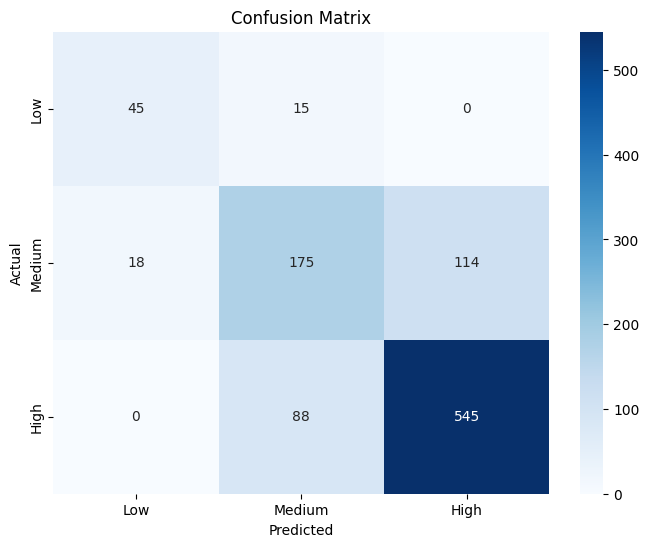

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



XGBoost

In [ ]:
from xgboost import XGBClassifier

# Initialize XGBoost
model = XGBClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-5-1316344997.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


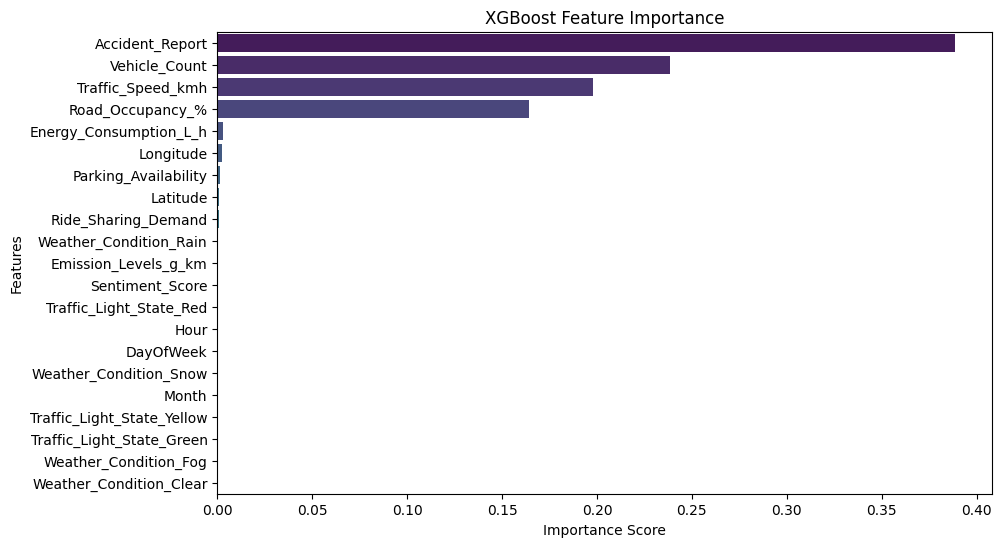


Feature Importance Scores:
                   Feature  Importance
           Accident_Report    0.388782
             Vehicle_Count    0.238291
         Traffic_Speed_kmh    0.197983
          Road_Occupancy_%    0.163938
    Energy_Consumption_L_h    0.003007
                 Longitude    0.002705
      Parking_Availability    0.001369
                  Latitude    0.000839
       Ride_Sharing_Demand    0.000808
    Weather_Condition_Rain    0.000582
      Emission_Levels_g_km    0.000462
           Sentiment_Score    0.000311
   Traffic_Light_State_Red    0.000258
                      Hour    0.000253
                 DayOfWeek    0.000207
    Weather_Condition_Snow    0.000207
                     Month    0.000000
Traffic_Light_State_Yellow    0.000000
 Traffic_Light_State_Green    0.000000
     Weather_Condition_Fog    0.000000
   Weather_Condition_Clear    0.000000


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        60
         1.0       1.00      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 59   1   0]
 [  0 307   0]
 [  0   0 633]]


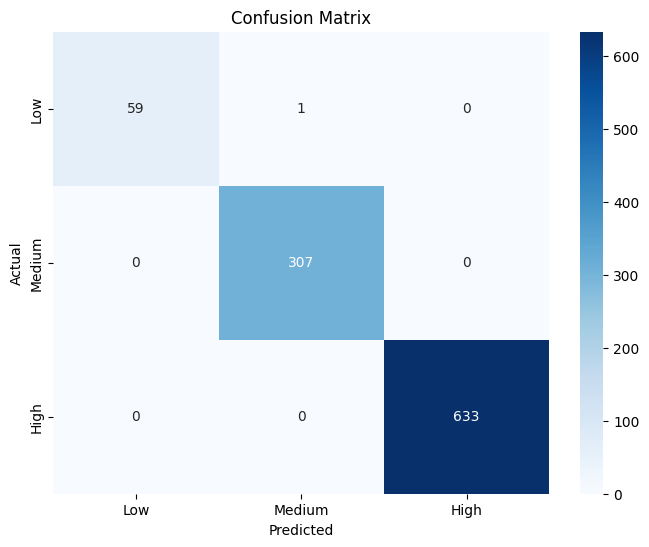

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 150],         # Number of trees
    'max_depth': [3, 5, 7],                 # Depth of each tree
    'learning_rate': [0.01, 0.1, 0.2],      # How fast the model learns
    'subsample': [0.8, 1.0],                # % of data used per tree
    'colsample_bytree': [0.8, 1.0]          # % of features used per tree
}

xgb = XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_macro',      # Or 'accuracy' or any other metric
    cv=5,                    # 5-fold cross-validation
    n_jobs=-1,               # Use all CPU cores
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score:", round(grid_search.best_score_, 4))

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:46:51] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.8}
Best F1 Score: 0.9971


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        60
         1.0       0.99      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 59   1   0]
 [  0 307   0]
 [  0   1 632]]


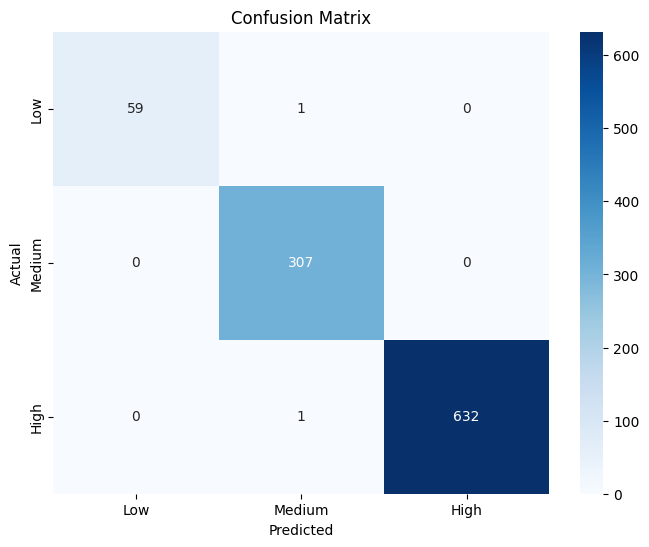

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(max_depth=10, random_state=42)
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

/tmp/ipython-input-5-3619992267.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


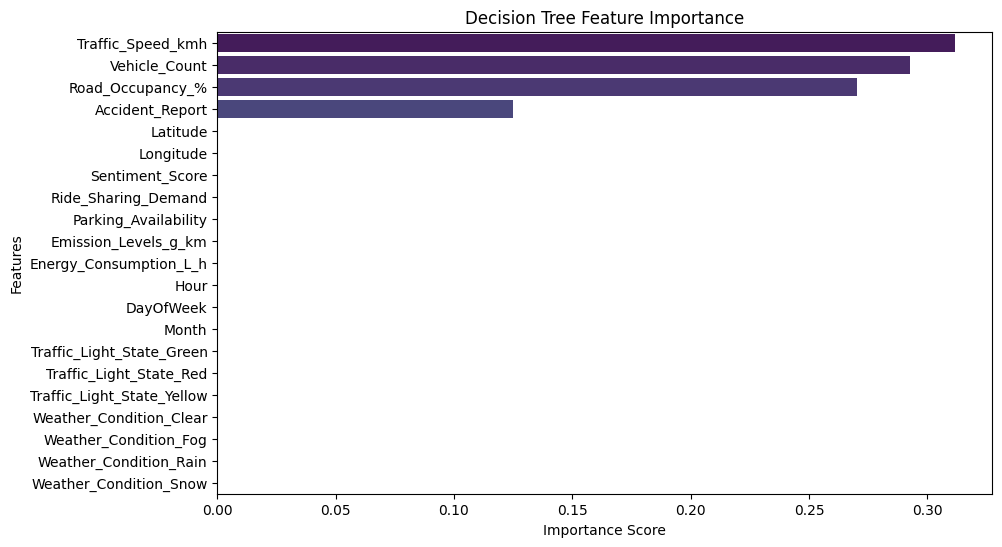


Feature Importance Scores:
                   Feature  Importance
         Traffic_Speed_kmh    0.311836
             Vehicle_Count    0.292871
          Road_Occupancy_%    0.270377
           Accident_Report    0.124916
                  Latitude    0.000000
                 Longitude    0.000000
           Sentiment_Score    0.000000
       Ride_Sharing_Demand    0.000000
      Parking_Availability    0.000000
      Emission_Levels_g_km    0.000000
    Energy_Consumption_L_h    0.000000
                      Hour    0.000000
                 DayOfWeek    0.000000
                     Month    0.000000
 Traffic_Light_State_Green    0.000000
   Traffic_Light_State_Red    0.000000
Traffic_Light_State_Yellow    0.000000
   Weather_Condition_Clear    0.000000
     Weather_Condition_Fog    0.000000
    Weather_Condition_Rain    0.000000
    Weather_Condition_Snow    0.000000


In [ ]:
# Check feature importance
importances = model.feature_importances_
feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Decision Tree Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Print raw importance values
print("\nFeature Importance Scores:")
print(importance_df.to_string(index=False))

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        60
         1.0       1.00      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 59   1   0]
 [  0 307   0]
 [  0   0 633]]


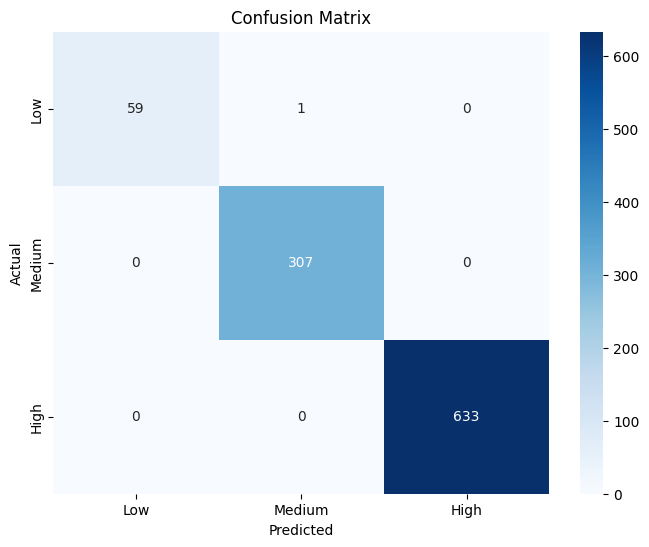

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    scoring='f1_macro',     # or 'accuracy', 'recall_macro', etc.
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best F1 Score (CV):", round(grid_search.best_score_, 4))

# Evaluate on test set
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best F1 Score (CV): 0.9998


Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

         0.0       1.00      0.98      0.99        60
         1.0       1.00      1.00      1.00       307
         2.0       1.00      1.00      1.00       633

    accuracy                           1.00      1000
   macro avg       1.00      0.99      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Confusion Matrix:
[[ 59   1   0]
 [  0 307   0]
 [  0   0 633]]


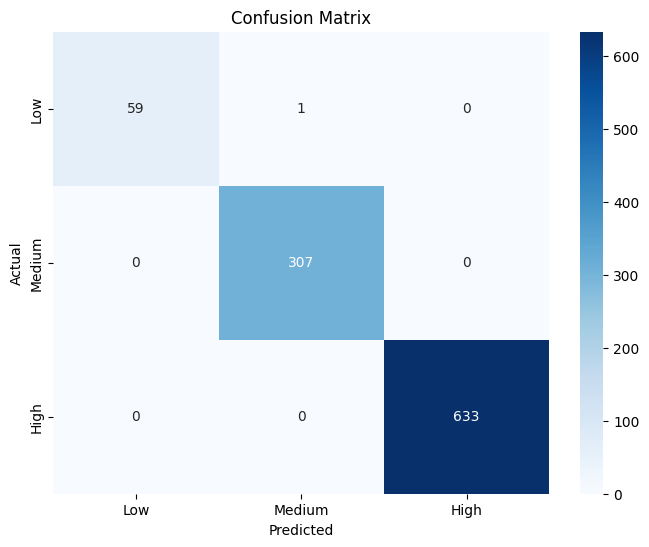

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



---



SVC

In [ ]:
from sklearn.svm import LinearSVC

model = LinearSVC(max_iter=10000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

/tmp/ipython-input-5-2901456680.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


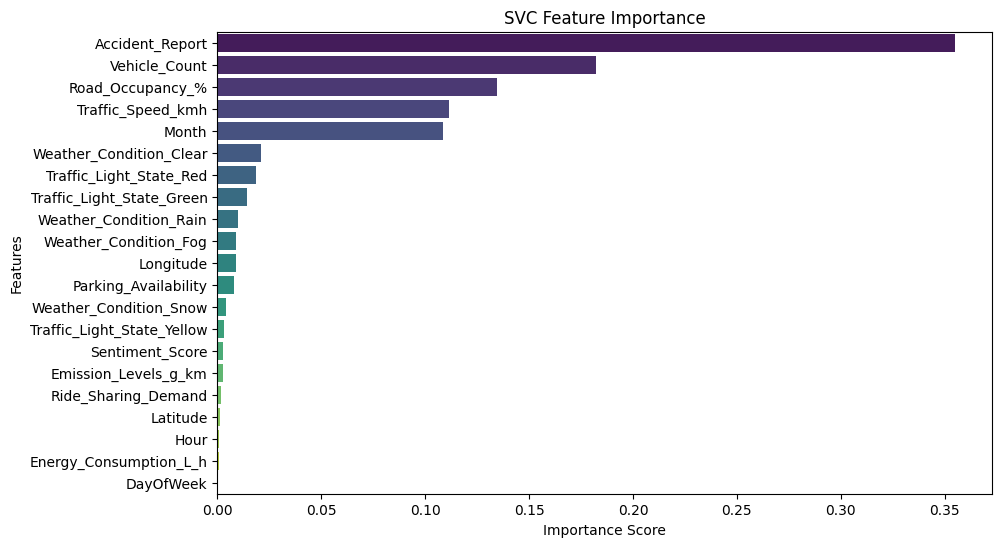


Feature Importance (Logistic Regression):
       Latitude: 0.001239
      Longitude: 0.009110
  Vehicle_Count: 0.182159
Traffic_Speed_kmh: 0.111509
Road_Occupancy_%: 0.134512
Accident_Report: 0.355132
Sentiment_Score: 0.002931
Ride_Sharing_Demand: 0.001959
Parking_Availability: 0.008245
Emission_Levels_g_km: 0.002909
Energy_Consumption_L_h: 0.000610
           Hour: 0.000616
      DayOfWeek: 0.000019
          Month: 0.108540
Traffic_Light_State_Green: 0.014491
Traffic_Light_State_Red: 0.018611
Traffic_Light_State_Yellow: 0.003078
Weather_Condition_Clear: 0.021005
Weather_Condition_Fog: 0.009128
Weather_Condition_Rain: 0.010121
Weather_Condition_Snow: 0.004074


In [ ]:
# Get feature importance
feature_importance = np.abs(model.coef_[0])
feature_importance = feature_importance / feature_importance.sum()

feature_names = X_train.columns

# Create a DataFrame for visualization
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('SVC Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.show()

# Create simple display (higher = more important)
print("\nFeature Importance (Logistic Regression):")
for feature, importance in zip(X_train.columns, feature_importance):
    print(f"{feature:>15}: {importance:.6f}")

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.55      0.62        60
         1.0       0.62      0.46      0.53       307
         2.0       0.79      0.91      0.84       633

    accuracy                           0.75      1000
   macro avg       0.70      0.64      0.66      1000
weighted avg       0.73      0.75      0.73      1000


Confusion Matrix:
[[ 33  27   0]
 [ 14 142 151]
 [  0  60 573]]


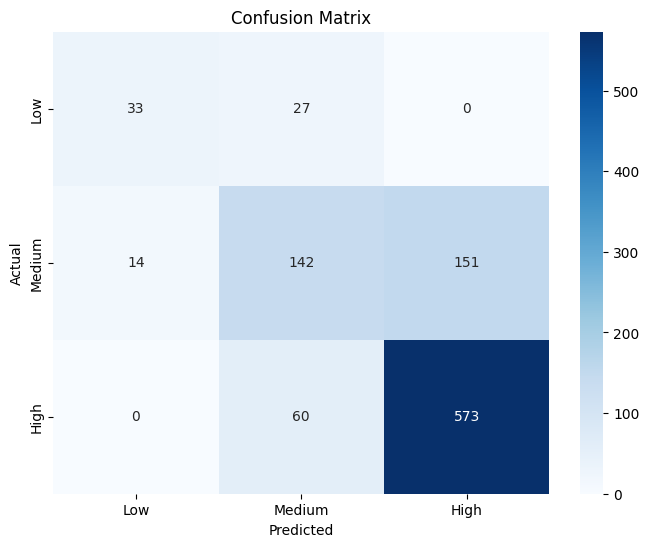

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid_linear_svc = {
    'C': [0.01, 0.1, 1, 10, 100],
    'loss': ['hinge', 'squared_hinge'],
    'penalty': ['l2'],
    'dual': [False, True]  # False when n_samples > n_features often helps
}

grid_linear_svc = GridSearchCV(model, param_grid_linear_svc, cv=5, scoring='accuracy', n_jobs=-1)
grid_linear_svc.fit(X_train, y_train)

print("Best LinearSVC Params:", grid_linear_svc.best_params_)
print("Best LinearSVC Score:", grid_linear_svc.best_score_)

best_svc_model = grid_linear_svc.best_estimator_
y_pred = best_svc_model.predict(X_test)

Best LinearSVC Params: {'C': 10, 'dual': False, 'loss': 'squared_hinge', 'penalty': 'l2'}
Best LinearSVC Score: 0.7735


/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
25 fits failed out of a total of 100.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
25 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.11/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/sklearn/svm/_classes.py", line 321, in fit
    self.coef_, self.intercept_, n_i

Accuracy: 0.75

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.55      0.62        60
         1.0       0.62      0.46      0.53       307
         2.0       0.79      0.91      0.84       633

    accuracy                           0.75      1000
   macro avg       0.70      0.64      0.66      1000
weighted avg       0.73      0.75      0.73      1000


Confusion Matrix:
[[ 33  27   0]
 [ 14 142 151]
 [  0  60 573]]


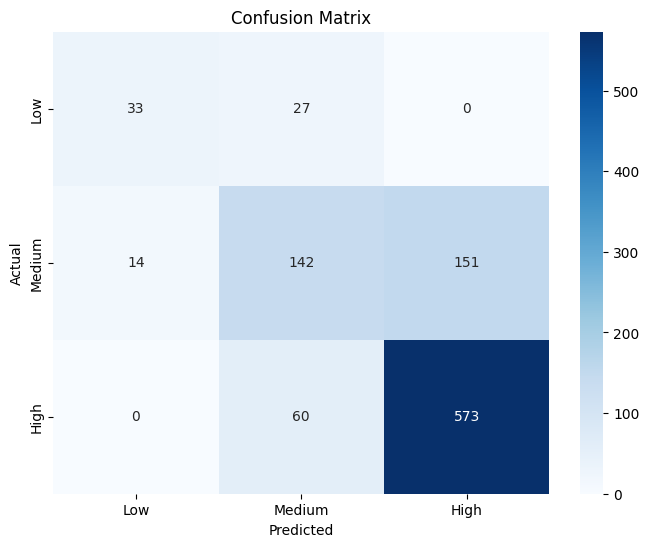

In [ ]:
# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Accuracy:", round(acc, 2))

# Classification report (includes precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix
labels = [0, 1, 2]
class_names = ['Low', 'Medium', 'High']
cm = confusion_matrix(y_test, y_pred, labels=labels)
print("\nConfusion Matrix:")
print(cm)

# Plot it nicely
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()